# 05 - Batch Inference

Purpose: run or review batch inference outputs for the champion model.

In [4]:
from pathlib import Path
import json
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyspark
from pyspark.sql import SparkSession, functions as F, Window

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
DATAMART_DIR = PROJECT_ROOT / "datamart"
MODEL_BANK_DIR = PROJECT_ROOT / "outputs" / "model_bank"
REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"

def spark_path(path):
    return Path(path).resolve().as_posix()

spark = (pyspark.sql.SparkSession.builder
         .appName("assignment_2_notebook")
         .master("local[*]")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

print(f"Project root: {PROJECT_ROOT}")
print(f"Spark version: {spark.version}")

Project root: /opt/airflow/project
Spark version: 3.5.1


In [5]:
RUN_INFERENCE = True

if RUN_INFERENCE:
    from utils.model_inference import run_batch_inference
    run_batch_inference()

predictions = spark.read.parquet(spark_path(DATAMART_DIR / "gold" / "model_predictions"))
print(f"Prediction rows: {predictions.count():,}")
display(predictions.limit(10).toPandas())

Saved gold/model_predictions: 8,974 rows
Prediction rows: 8,974


,Customer_ID,loan_id,feature_snapshot_date,label_snapshot_date,model_version,dataset_split,prediction_score,prediction_label,scored_at
0,CUS_0x3873,CUS_0x3873_2023_01_01,2023-01-01,2023-07-01,20260627_115934,train,0.087199,0,2026-06-27T12:01:56.573501+00:00
1,CUS_0xa146,CUS_0xa146_2023_01_01,2023-01-01,2023-07-01,20260627_115934,train,0.193561,0,2026-06-27T12:01:56.573501+00:00
2,CUS_0x3061,CUS_0x3061_2023_02_01,2023-02-01,2023-08-01,20260627_115934,train,0.303647,1,2026-06-27T12:01:56.573501+00:00
3,CUS_0x8afa,CUS_0x8afa_2023_02_01,2023-02-01,2023-08-01,20260627_115934,train,0.711118,1,2026-06-27T12:01:56.573501+00:00
4,CUS_0x2da6,CUS_0x2da6_2023_03_01,2023-03-01,2023-09-01,20260627_115934,train,0.183668,0,2026-06-27T12:01:56.573501+00:00
5,CUS_0x98d4,CUS_0x98d4_2023_03_01,2023-03-01,2023-09-01,20260627_115934,train,0.080176,0,2026-06-27T12:01:56.573501+00:00
6,CUS_0xafda,CUS_0xafda_2023_03_01,2023-03-01,2023-09-01,20260627_115934,train,0.231144,0,2026-06-27T12:01:56.573501+00:00
7,CUS_0x1a87,CUS_0x1a87_2023_05_01,2023-05-01,2023-11-01,20260627_115934,train,0.123660,0,2026-06-27T12:01:56.573501+00:00
8,CUS_0x2c18,CUS_0x2c18_2023_05_01,2023-05-01,2023-11-01,20260627_115934,train,0.735848,1,2026-06-27T12:01:56.573501+00:00
9,CUS_0x464f,CUS_0x464f_2023_05_01,2023-05-01,2023-11-01,20260627_115934,train,0.129660,0,2026-06-27T12:01:56.573501+00:00


In [6]:
prediction_profile = (predictions.groupBy("dataset_split").agg(F.count("*").alias("row_count"),
        F.avg("prediction_score").alias("avg_prediction_score"),
        F.expr("percentile_approx(prediction_score, 0.5)").alias("median_prediction_score"),
        F.avg("prediction_label").alias("predicted_default_rate")).orderBy("dataset_split"))
display(prediction_profile.toPandas())

,dataset_split,row_count,avg_prediction_score,median_prediction_score,predicted_default_rate
0,oot,2013,0.288981,0.188190,0.364630
1,test,1983,0.288837,0.186620,0.362078
2,train,4978,0.279689,0.181479,0.339293


In [7]:
monthly_scores = (predictions.withColumn("monitoring_month", F.date_format("feature_snapshot_date", "yyyy-MM"))
                  .groupBy("monitoring_month", "dataset_split")
                  .agg(F.count("*").alias("row_count"),
                       F.avg("prediction_score").alias("avg_prediction_score"),
                       F.avg("prediction_label").alias("predicted_default_rate"))
                  .orderBy("monitoring_month", "dataset_split").toPandas())
display(monthly_scores)

,monitoring_month,dataset_split,row_count,avg_prediction_score,predicted_default_rate
0,2023-01,train,530,0.261805,0.311321
1,2023-02,train,501,0.281109,0.349301
2,2023-03,train,506,0.293384,0.361660
3,2023-04,train,510,0.275378,0.339216
4,2023-05,train,521,0.284884,0.345489
5,2023-06,train,517,0.263576,0.303675
6,2023-07,train,471,0.303204,0.380042
7,2023-08,train,481,0.284430,0.347193
8,2023-09,train,454,0.275201,0.334802
9,2023-10,train,487,0.276281,0.324435


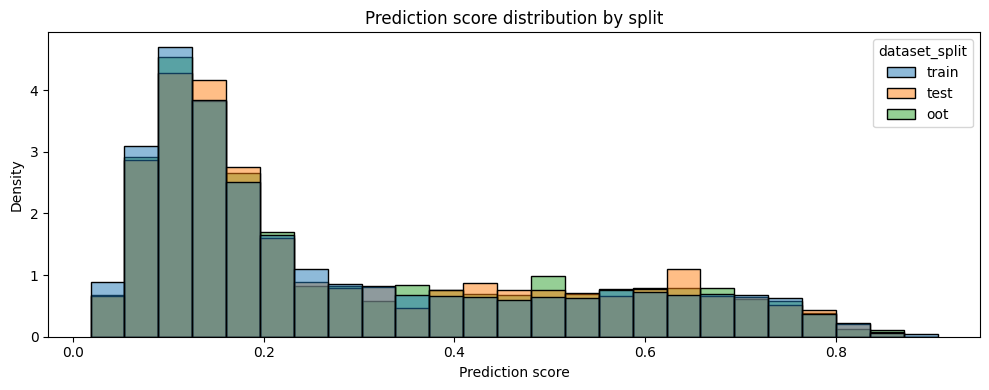

In [8]:
pred_pd = predictions.select("dataset_split", "prediction_score").toPandas()
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(data=pred_pd, x="prediction_score", hue="dataset_split", bins=25, stat="density", common_norm=False, ax=ax)
ax.set_title("Prediction score distribution by split")
ax.set_xlabel("Prediction score")
plt.tight_layout()

In [9]:
feature_store = spark.read.parquet(spark_path(DATAMART_DIR / "gold" / "feature_store"))
scored = predictions.join(feature_store.select("Customer_ID", "loan_id", "feature_snapshot_date", "label_snapshot_date", "label"),
                          ["Customer_ID", "loan_id", "feature_snapshot_date", "label_snapshot_date"],"inner")
display(scored.groupBy("dataset_split").agg(F.count("*").alias("row_count"),
                                            F.avg("label").alias("actual_default_rate"),
                                            F.avg("prediction_label").alias("predicted_default_rate"))
        .orderBy("dataset_split").toPandas())

,dataset_split,row_count,actual_default_rate,predicted_default_rate
0,oot,2013,0.305017,0.364630
1,test,1983,0.295008,0.362078
2,train,4978,0.279630,0.339293
